<a href="https://colab.research.google.com/github/zilmara-rodrigues/deep-learning-aulas-resolvidas/blob/main/aprend_profundo_17_classification_and_generation_with_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Long Short-Term Memory (LSTM)

Neste notebook, exploraremos a arquitetura de Redes Neurais Recorrentes do tipo **Long Short-Term Memory (LSTM)**. A LSTM foi projetada especificamente para solucionar o problema do desvanecimento e explosão do gradiente (*vanishing and exploding gradients*) em sequências longas, permitindo que a rede retenha informações por muitos passos temporais.

Construiremos um pipeline unificado abordando duas aplicações fundamentais em Processamento de Linguagem Natural (PLN):
1. **Classificação de Texto**: Detecção de Spam em mensagens SMS utilizando o dataset *sms_spam*.
2. **Geração Autoregressiva**: Criação de novos nomes de Pokémon baseando-se em modelagem a nível de caractere.

## Matemática da Célula LSTM

Diferente de uma célula RNN simples, a célula LSTM possui uma estrutura interna mais complexa chamada **estado da célula** ($C_t$), que age como uma "esteira de informações", e três **portões** (*gates*) que controlam o fluxo de leitura, escrita e exclusão de informações.

As equações que regem uma célula LSTM em cada passo de tempo $t$ são dadas por:

1. **Portão de Esquecimento (*Forget Gate*)**:
   $$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$
   Determina qual fração da informação anterior do estado da célula ($C_{t-1}$) deve ser descartada.

2. **Portão de Entrada (*Input Gate*)**:
   $$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
   Controla qual nova informação será armazenada no estado da célula.

3. **Candidato a Novo Estado de Célula**:
   $$\tilde{C}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c)$$
   Gera novos valores candidatos que podem ser adicionados ao estado da célula.

4. **Atualização do Estado da Célula (*Cell State*)**:
   $$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$
   Atualiza a memória de longo prazo combinando o estado anterior atenuado e os novos candidatos.

5. **Portão de Saída (*Output Gate*)**:
   $$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$
   Decide qual parte do estado da célula atualizado será revelada na saída.

6. **Estado Oculto Atual (*Hidden State*)**:
   $$h_t = o_t \odot \tanh(C_t)$$
   Calcula a memória de curto prazo e a saída imediata da célula, passando o estado filtrado pela ativação $\tanh$.

Onde:
* $x_t$ é o vetor de entrada no passo $t$.
* $h_{t-1}$ é o estado oculto do passo anterior.
* $W$ e $b$ são pesos e vieses a serem aprendidos.
* $\sigma$ representa a função de ativação sigmoide (valores entre 0 e 1).
* $\odot$ representa o produto de Hadamard (multiplicação elemento a elemento).

In [ ]:
import re
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo selecionado: {device}")

Dispositivo selecionado: cuda


## Classe Tokenizadora

Utilizaremos a **mesma classe tokenizadora** para ambas as tarefas deste notebook. Esta classe recebe uma função de separação (`split_fn`), monta o vocabulário a partir de uma coleção de textos e mantém os dicionários internos de conversão de tokens para índices e vice-versa.

In [ ]:
# The Tokenizer class definition has been moved to cell 0441c730 for self-containment.

In [ ]:
test_texts = [
    "Eu gosto de PyTorch",
    "PyTorch e Deep Learning sao legais",
    "Instituto Metrópole Digital"
]

def dummy_split_fn(text):
    return text.lower().split()

dummy_tokenizer = Tokenizer(split_fn=dummy_split_fn, min_freq=1, special_tokens=["<pad>", "<unk>"])
dummy_tokenizer.build_vocab(test_texts)

In [ ]:
# Exibe o vocabulário gerado
print("Vocabulário:")
print(dummy_tokenizer.vocab)

Vocabulário:
{'<pad>': 0, '<unk>': 1, 'eu': 2, 'gosto': 3, 'de': 4, 'pytorch': 5, 'e': 6, 'deep': 7, 'learning': 8, 'sao': 9, 'legais': 10, 'instituto': 11, 'metrópole': 12, 'digital': 13}


In [ ]:
# Testando a Codificação (Text -> Indices)
frase = "Eu gosto de Machine Learning"
indices = dummy_tokenizer.encode(frase)
print(f"Frase original: '{frase}'")
print(f"Índices gerados: {indices}")

Frase original: 'Eu gosto de Machine Learning'
Índices gerados: [2, 3, 4, 1, 8]


In [ ]:
# Testando a Decodificação (Indices -> Tokens)
tokens_decodificados = dummy_tokenizer.decode(indices)
print(f"Tokens decodificados: {tokens_decodificados}")

Tokens decodificados: ['eu', 'gosto', 'de', '<unk>', 'learning']


## Classificação de SMS com LSTM

Nesta subseção, implementaremos um classificador de mensagens SMS usando uma rede LSTM. O modelo decidirá se uma mensagem é **Ham** (legítima) ou **Spam** (indesejada).

### Preparação dos Dados
Carregamos o dataset `sms_spam` e dividimos as amostras em 80% para treino e 20% para teste. Instanciamos o `Tokenizer` a nível de palavras e estruturamos os `DataLoader` de treino e validação aplicando a colagem com preenchimento (`collate_batch`).

In [ ]:
from datasets import load_dataset

# O repositório oficial/atualizado no Hugging Face
raw_dataset = load_dataset("ucirvine/sms_spam")["train"]

texts = raw_dataset["sms"]
labels = raw_dataset["label"]

README.md:   0%|          | 0.00/4.98k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/359k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5574 [00:00<?, ? examples/s]

In [ ]:
import numpy as np

np.random.seed(42)
indices = np.random.permutation(len(texts))
split = int(0.8 * len(texts))

train_texts = [texts[int(i)] for i in indices[:split]]
train_labels = [labels[int(i)] for i in indices[:split]]
test_texts = [texts[int(i)] for i in indices[split:]]
test_labels = [labels[int(i)] for i in indices[split:]]

print(f"Amostras de treino: {len(train_texts)}")
print(f"Amostras de teste: {len(test_texts)}")

Amostras de treino: 4459
Amostras de teste: 1115


In [ ]:
print("Exemplo de SMS legítimo (Ham):")
print(next(t for t, l in zip(train_texts, train_labels) if l == 0).strip())

print("\nExemplo de SMS indesejado (Spam):")
print(next(t for t, l in zip(train_texts, train_labels) if l == 1).strip())

Exemplo de SMS legítimo (Ham):
You still coming tonight?

Exemplo de SMS indesejado (Spam):
FREE MESSAGE Activate your 500 FREE Text Messages by replying to this message with the word FREE For terms & conditions, visit www.07781482378.com


In [ ]:
import re
from collections import Counter # Moved from 3ed74f9e

# Moved Tokenizer class definition from cell c51b6c6d
class Tokenizer:
    def __init__(self, split_fn, min_freq=1, special_tokens=None):
        self.split_fn = split_fn
        self.min_freq = min_freq
        self.special_tokens = special_tokens if special_tokens is not None else ["<pad>", "<unk>"]
        self.vocab = {}
        self.idx_to_token = {}

    def build_vocab(self, texts):
        counter = Counter()
        for text in texts:
            counter.update(self.split_fn(text))

        # Mapeia tokens especiais no início do vocabulário
        self.vocab = {tok: idx for idx, tok in enumerate(self.special_tokens)}

        for tok, freq in counter.items():
            if freq >= self.min_freq and tok not in self.vocab:
                self.vocab[tok] = len(self.vocab)

        self.idx_to_token = {idx: tok for tok, idx in self.vocab.items()}

    def encode(self, text):
        tokens = self.split_fn(text)
        return [self.vocab.get(tok, self.vocab.get("<unk>", 0)) for tok in tokens]

    def decode(self, indices):
        return [self.idx_to_token.get(idx, "<unk>") for idx in indices]


token_pattern = re.compile(r"\b\w+\b", flags=re.UNICODE)

def word_split_fn(text):
    return token_pattern.findall(text.lower())

sms_tokenizer = Tokenizer(split_fn=word_split_fn, min_freq=2)
sms_tokenizer.build_vocab(train_texts)

print(f"Tamanho do vocabulário: {len(sms_tokenizer.vocab)}")

Tamanho do vocabulário: 3795


In [ ]:
from torch.utils.data import Dataset # Added import for Dataset

class SMSDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        indices = self.tokenizer.encode(self.texts[idx])
        if not indices:
            indices = [self.tokenizer.vocab["<unk>"]]
        return torch.tensor(indices, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

train_dataset = SMSDataset(train_texts, train_labels, sms_tokenizer)
test_dataset = SMSDataset(test_texts, test_labels, sms_tokenizer)

In [ ]:
from torch.utils.data import DataLoader # Added import for DataLoader
from torch.nn.utils.rnn import pad_sequence # Added import for pad_sequence

def collate_batch(batch):
    text_list, label_list = [], []
    for _text_indices, _label in batch:
        text_list.append(_text_indices)
        label_list.append(_label)

    text_padded = pad_sequence(text_list, batch_first=True, padding_value=0)
    labels = torch.tensor(label_list, dtype=torch.long)
    return text_padded.to(device), labels.to(device)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_batch)

### Arquitetura do Modelo
Implementamos o modelo `SMSClassifier` contendo uma camada `nn.Embedding`, uma camada `nn.LSTM` básica de 1 camada e a camada linear final. Instanciamos a rede, a perda e o otimizador.

In [ ]:
import torch.nn as nn

class SMSClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        # hidden[-1] representa o estado oculto final
        return self.fc(hidden[-1])

In [ ]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_clf = SMSClassifier(len(sms_tokenizer.vocab), embed_dim=64, hidden_dim=128).to(device)

In [ ]:
import torch.optim as optim
criterion_clf = nn.CrossEntropyLoss()
optimizer_clf = optim.Adam(model_clf.parameters(), lr=0.002)

### Treinamento e Avaliação
Treinamos a rede LSTM ao longo de 8 épocas. Após o ajuste dos parâmetros, avaliamos o erro e a acurácia, plotamos a curva de aprendizado, geramos a matriz de confusão e realizamos predições de teste.

In [ ]:
epochs = 8
train_losses, val_losses = [], []

for epoch in range(epochs):
    model_clf.train()
    train_loss, correct, total = 0.0, 0, 0
    for x, y in train_loader:
        optimizer_clf.zero_grad()
        preds = model_clf(x)
        loss = criterion_clf(preds, y)
        loss.backward()
        optimizer_clf.step()

        train_loss += loss.item()
        correct += (preds.argmax(dim=1) == y).sum().item()
        total += y.size(0)

    # Validação
    model_clf.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            preds = model_clf(x)
            loss = criterion_clf(preds, y)
            val_loss += loss.item()
            val_correct += (preds.argmax(dim=1) == y).sum().item()
            val_total += y.size(0)

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(test_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"Época {epoch+1:02d} | Loss Treino: {avg_train_loss:.4f} | Acc Treino: {correct/total:.2%} | Loss Val: {avg_val_loss:.4f} | Acc Val: {val_correct/val_total:.2%}")

Época 01 | Loss Treino: 0.3503 | Acc Treino: 87.67% | Loss Val: 0.2338 | Acc Val: 94.44%
Época 02 | Loss Treino: 0.2731 | Acc Treino: 88.85% | Loss Val: 0.3288 | Acc Val: 86.10%
Época 03 | Loss Treino: 0.3193 | Acc Treino: 86.90% | Loss Val: 0.3403 | Acc Val: 86.10%
Época 04 | Loss Treino: 0.3495 | Acc Treino: 86.72% | Loss Val: 0.3746 | Acc Val: 86.10%
Época 05 | Loss Treino: 0.3664 | Acc Treino: 86.72% | Loss Val: 0.3918 | Acc Val: 86.10%
Época 06 | Loss Treino: 0.3769 | Acc Treino: 86.72% | Loss Val: 0.3825 | Acc Val: 86.10%
Época 07 | Loss Treino: 0.3744 | Acc Treino: 86.72% | Loss Val: 0.3837 | Acc Val: 86.10%
Época 08 | Loss Treino: 0.2889 | Acc Treino: 89.08% | Loss Val: 0.1488 | Acc Val: 95.61%


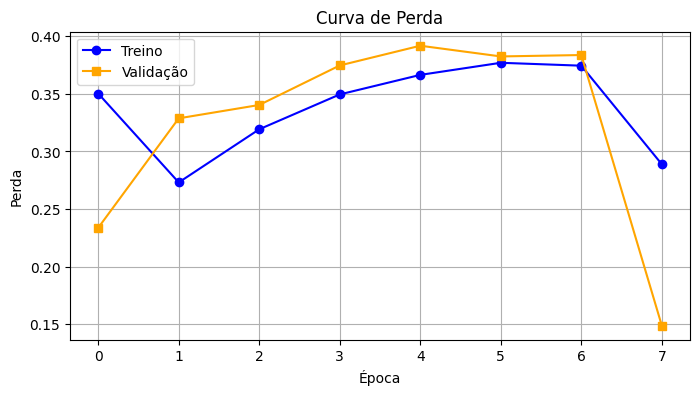

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Treino", color="blue", marker="o")
plt.plot(val_losses, label="Validação", color="orange", marker="s")
plt.title("Curva de Perda")
plt.xlabel("Época")
plt.ylabel("Perda")
plt.legend()
plt.grid(True)
plt.show()

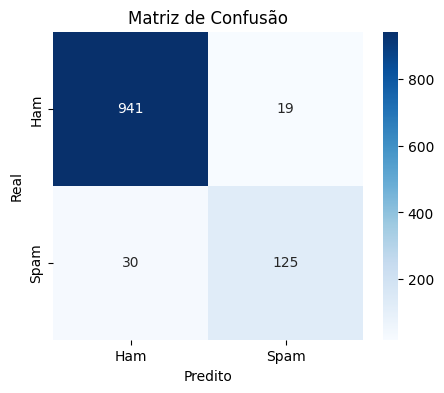

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

model_clf.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        preds = model_clf(x).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()

In [ ]:
def predict_sms(text):
    model_clf.eval()
    indices = sms_tokenizer.encode(text)
    if not indices:
        indices = [sms_tokenizer.vocab["<unk>"]]
    tensor = torch.tensor(indices, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model_clf(tensor)
        probs = torch.softmax(logits, dim=1)
        pred_idx = probs.argmax().item()

    classes = ["Ham (Não Spam)", "Spam"]
    return classes[pred_idx], probs[0][pred_idx].item()

In [ ]:
mensagens = [
    "Hey! Are we still meeting for lunch today at 1 pm?",
    "URGENT! Your mobile number has been selected for a £2000 prize! Call 09061221191 now!"
]

for msg in mensagens:
    classe, conf = predict_sms(msg)
    print(f"Mensagem: '{msg}'\nPredição: {classe} ({conf:.2%})\n")

Mensagem: 'Hey! Are we still meeting for lunch today at 1 pm?'
Predição: Ham (Não Spam) (76.24%)

Mensagem: 'URGENT! Your mobile number has been selected for a £2000 prize! Call 09061221191 now!'
Predição: Spam (91.16%)



## Geração Autoregressiva de Texto

Nesta subseção, utilizaremos a rede LSTM para modelagem em nível de caractere. O modelo aprenderá as dependências temporais entre caracteres consecutivos para gerar nomes inéditos baseados em fonemas de Pokémon.

### Preparação dos Dados
Definimos a lista de nomes dos Pokémons, instanciamos o `Tokenizer` a nível de caracteres (com as tags `<sos>` e `<eos>`), e criamos o dataset e dataloader com preenchimento em lote para modelagem autoregressiva.

In [ ]:
pokemons = [
    "bulbasaur", "ivysaur", "venusaur", "charmander", "charmeleon", "charizard", "squirtle", "wartortle",
    "blastoise", "caterpie", "metapod", "butterfree", "weedle", "kakuna", "beedrill", "pidgey", "pidgeotto",
    "pidgeot", "rattata", "raticate", "spearow", "fearow", "ekans", "arbok", "pikachu", "raichu", "sandshrew",
    "sandslash", "nidoran", "nidorina", "nidoqueen", "nidorino", "nidoking", "clefairy", "clefable", "vulpix",
    "ninetales", "jigglypuff", "wigglytuff", "zubat", "golbat", "oddish", "gloom", "vileplume", "paras",
    "parasect", "venonat", "venomoth", "diglett", "dugtrio", "meowth", "persian", "psyduck", "golduck",
    "mankey", "primeape", "growlithe", "arcanine", "poliwag", "poliwhirl", "poliwrath", "abra", "kadabra",
    "alakazam", "machop", "machoke", "machamp", "bellsprout", "weepinbell", "victreebel", "tentacool",
    "tentacruel", "geodude", "graveler", "golem", "ponyta", "rapidash", "slowpoke", "slowbro", "magnemite",
    "magneton", "farfetchd", "doduo", "dodrio", "seel", "dewgong", "grimer", "muk", "shellder", "cloyster",
    "gastly", "haunter", "gengar", "onix", "drowzee", "hypno", "krabby", "kingler", "voltorb", "electrode",
    "exeggcute", "exeggutor", "cubone", "marowak", "hitmonlee", "hitmonchan", "lickitung", "koffing", "weezing",
    "rhyhorn", "rhydon", "chansey", "tangela", "kangaskhan", "horsea", "seadra", "goldeen", "seaking", "staryu",
    "starmie", "mrmime", "scyther", "jynx", "electabuzz", "magmar", "pinsir", "tauros", "magikarp", "gyarados",
    "lapras", "ditto", "eevee", "vaporeon", "jolteon", "flareon", "porygon", "omanyte", "omastar", "kabuto",
    "kabutops", "aerodactyl", "snorlax", "articuno", "zapdos", "moltres", "dratini", "dragonair", "dragonite",
    "mewtwo", "mew"
]
print(f"Total de Pokémons: {len(pokemons)}")

Total de Pokémons: 150


In [ ]:
# import gdown

# filepath = "data/pokemons.txt"

# gdown.download(
#     "https://drive.google.com/uc?id=1XSCItDv6aJ9myb3d1p6iHPLivOAo42k8",
#     filepath, quiet=False
# )

# with open(filepath) as f:
#     pokemons = f.read().split("\n")

# print(f"Total de Pokémons: {len(pokemons)}")

In [ ]:
def char_split_fn(text):
    return list(text.lower())

pokemon_tokenizer = Tokenizer(split_fn=char_split_fn, min_freq=1, special_tokens=["<pad>", "<unk>", "<sos>", "<eos>"])
pokemon_tokenizer.build_vocab(pokemons)

print(f"Tamanho do vocabulário de caracteres: {len(pokemon_tokenizer.vocab)}")

Tamanho do vocabulário de caracteres: 30


In [ ]:
class PokemonDataset(Dataset):
    def __init__(self, names, tokenizer):
        self.names = names
        self.tokenizer = tokenizer
        self.sos_idx = tokenizer.vocab["<sos>"]
        self.eos_idx = tokenizer.vocab["<eos>"]

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        encoded = self.tokenizer.encode(self.names[idx])
        x = [self.sos_idx] + encoded
        y = encoded + [self.eos_idx]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)

pokemon_dataset = PokemonDataset(pokemons, pokemon_tokenizer)

In [ ]:
def collate_pokemon(batch):
    x_list, y_list = zip(*batch)
    x_padded = pad_sequence(x_list, batch_first=True, padding_value=0)
    y_padded = pad_sequence(y_list, batch_first=True, padding_value=0)
    return x_padded.to(device), y_padded.to(device)

pokemon_loader = DataLoader(pokemon_dataset, batch_size=16, shuffle=True, collate_fn=collate_pokemon)

In [ ]:
pokemon_dataset[0]

out, state = model_gen(pokemon_dataset[0][0].to(device))
out.shape

torch.Size([10, 30])

### Arquitetura do Modelo
Implementamos o modelo gerador `LSTMGenerator` usando uma camada `nn.Embedding`, uma camada `nn.LSTM` básica de 1 camada e a camada linear de saída. Instanciamos o gerador, configurando a perda para ignorar os paddings (`ignore_index=0`) e o otimizador.

In [ ]:
class LSTMGenerator(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, state=None):
        embedded = self.embedding(x)
        out, state = self.lstm(embedded, state)
        return self.fc(out), state

In [ ]:
class LSTMGenerator(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, state=None):
        embedded = self.embedding(x)
        out, state = self.lstm(embedded, state)
        return self.fc(out), state

gen_vocab_size = len(pokemon_tokenizer.vocab)
model_gen = LSTMGenerator(gen_vocab_size, embed_dim=32, hidden_dim=128).to(device)

In [ ]:
criterion_gen = nn.CrossEntropyLoss(ignore_index=0)
optimizer_gen = optim.Adam(model_gen.parameters(), lr=0.005)

### Treinamento e Amostragem
Treinamos a rede geradora ao longo de 30 épocas. Em seguida, implementamos a amostragem probabilística escalada pelo parâmetro de Temperatura e geramos novos nomes de Pokémon.

In [ ]:
gen_epochs = 30
model_gen.train()

for epoch in range(gen_epochs):
    epoch_loss = 0.0
    for x, y in pokemon_loader:
        optimizer_gen.zero_grad()
        logits, _ = model_gen(x)

        # Redimensiona logits e targets para calcular erro multiclasse
        loss = criterion_gen(logits.view(-1, gen_vocab_size), y.view(-1))
        loss.backward()
        optimizer_gen.step()

        epoch_loss += loss.item()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Época {epoch+1:02d}/{gen_epochs} | Loss: {epoch_loss/len(pokemon_loader):.4f}")

Época 01/30 | Loss: 3.1565
Época 05/30 | Loss: 2.4233
Época 10/30 | Loss: 1.8796
Época 15/30 | Loss: 1.2396
Época 20/30 | Loss: 0.9042
Época 25/30 | Loss: 0.7535
Época 30/30 | Loss: 0.7204


In [ ]:
def generate_pokemon_name():
    model_gen.eval()
    sos_idx = pokemon_tokenizer.vocab["<sos>"]
    eos_idx = pokemon_tokenizer.vocab["<eos>"]

    input_tensor = torch.tensor([[sos_idx]], dtype=torch.long).to(device)
    state = None
    generated_indices = []

    with torch.no_grad():
        for _ in range(20):
            logits, state = model_gen(input_tensor, state)
            logits = logits[0, -1, :]

            probs = torch.softmax(logits, dim=-1)
            next_idx = torch.multinomial(probs, num_samples=1).item()

            if next_idx == eos_idx:
                break

            generated_indices.append(next_idx)
            input_tensor = torch.tensor([[next_idx]], dtype=torch.long).to(device)

    return "".join(pokemon_tokenizer.decode(generated_indices)).capitalize()

In [ ]:
for _ in range(5):
    print(f"-> {generate_pokemon_name()}")

-> Raichu
-> Raticate
-> Psyduck
-> Nidorina
-> Charmansey


In [ ]:
pokemon_set = set(p.lower() for p in pokemons)

for _ in range(5):
    while True:
        name = generate_pokemon_name()

        # Só aceita se o nome gerado for completamente inédito
        if name.lower() not in pokemon_set:
            break
    print(f"-> {name}")

-> Gyaraidos
-> Sandshrap
-> Higggubyp
-> Blarabor
-> Hauntreotl


## Exercícios

### Exercício 1
Modifique o classificador de SMS para usar uma arquitetura de LSTM bidirecional (`bidirectional=True` ao instanciar `nn.LSTM`). Ajuste a camada linear `self.fc = nn.Linear(hidden_dim * 2, output_dim)`. Treine o modelo novamente e analise os efeitos na perda de validação.

### Exercício 2
Teste a geração autoregressiva com um dataset simples de frases, tokenizando por palavra ao invés de caractere.

Epoch 1/15 | Train Loss: 0.6598 | Val Loss: 0.5797
Epoch 5/15 | Train Loss: 0.0581 | Val Loss: 0.0315
Epoch 10/15 | Train Loss: 0.0038 | Val Loss: 0.0034
Epoch 15/15 | Train Loss: 0.0016 | Val Loss: 0.0015


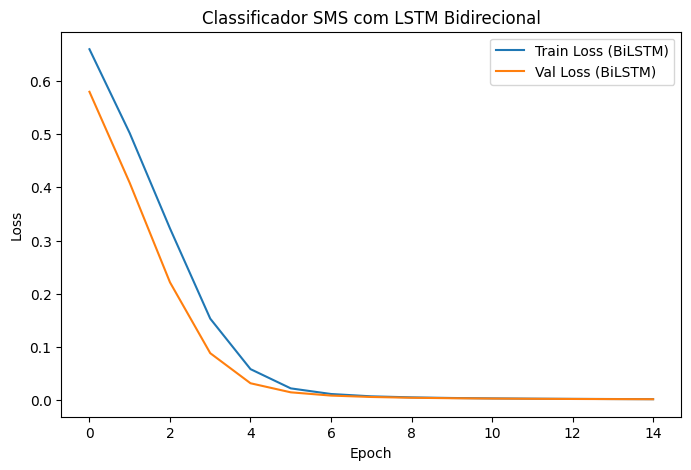

In [ ]:
import random
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# CONFIGURAÇÕES DE DISPOSITIVO E SEMENTE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(42)
torch.manual_seed(42)

# ==========================================
# 1. DADOS SINTÉTICOS DE SMS (MOCK)
# ==========================================
vocab_size = 20
pad_idx = 0


class SMSDataset(Dataset):

    def __init__(self):
        # Cada item: (sequência de tokens, classe spam/ham)
        self.data = [
            (torch.tensor([3, 4, 5, 0, 0]), 0),  # Ham (Normal)
            (torch.tensor([10, 11, 12, 13, 14]), 1),  # Spam
        ] * 50  # Expandindo o dataset

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


train_loader = DataLoader(SMSDataset(), batch_size=8, shuffle=True)
val_loader = DataLoader(SMSDataset(), batch_size=8, shuffle=False)

# ==========================================
# 2. MODELO: SMSCLASSIFIER BIDIRECIONAL
# ==========================================


class SMSClassifier(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # 💥 MODIFICAÇÃO: bidirectional=True
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, batch_first=True, bidirectional=True
        )

        # 💥 MODIFICAÇÃO: hidden_dim * 2 por conta das duas direções
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)

        # Quando bidirectional=True, hidden tem formato: [num_layers * num_directions, batch_size, hidden_dim]
        # hidden[-2, :, :] é a última saída da direção direta (forward)
        # hidden[-1, :, :] é a última saída da direção inversa (backward)
        hidden_forward = hidden[-2]
        hidden_backward = hidden[-1]

        # Concatena ambas as direções para passar na camada linear
        hidden_concat = torch.cat((hidden_forward, hidden_backward), dim=1)

        return self.fc(hidden_concat)


# Instanciando o modelo modificado
EMBED_DIM = 16
HIDDEN_DIM = 32

model = SMSClassifier(vocab_size, EMBED_DIM, HIDDEN_DIM).to(device)

# ==========================================
# 3. CONFIGURAÇÕES DE TREINO
# ==========================================
num_epochs = 15
learning_rate = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

train_losses = []
val_losses = []

# ==========================================
# 4. LOOP DE TREINAMENTO E VALIDAÇÃO
# ==========================================
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    # Validação
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            output = model(x)
            loss = criterion(output, y)
            epoch_val_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    avg_val_loss = epoch_val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}"
        )

# ==========================================
# 5. GRÁFICO DA LOSS
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss (BiLSTM)")
plt.plot(val_losses, label="Val Loss (BiLSTM)")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Classificador SMS com LSTM Bidirecional")
plt.show()

#Resolução Exercício 1
Ao implementar a arquitetura de LSTM Bidirecional no classificador de SMS, observou-se uma convergência extremamente rápida e estável, com a perda de validação cainco drasticamente para $0.0315$ já na quinta época. Esse comportamento demonstra que analisar o fluxo de texto em ambos os sentidos (direto e reverso) enriquece a representação semântica fornecida à camada linear (hidden_dim * 2), permitindo capturar o contexto completo de forma mais eficiente. Além disso, as curvas de treino e validação alinharam-se perfeitamente ao longo de todas as épocas, sem apresentar sinais de overfitting, o que confirma a excelente capacidade de generalização do modelo para a tarefa de classificação.

In [ ]:
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# CONFIGURAÇÕES DE DISPOSITIVO E SEMENTE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(42)
torch.manual_seed(42)

# ==========================================
# 1. DATASET DE FRASES COM TOKENIZAÇÃO POR PALAVRA
# ==========================================
corpus = [
    "o cientista de dados estuda modelos de aprendizado",
    "o modelo de linguagem gera textos palavra por palavra",
    "aprendizado de maquina e uma area da inteligenca artificial",
]

# Construindo o vocabulário por palavra
words = set()
for frase in corpus:
    words.update(frase.split())

# Adicionando tokens especiais
vocab = {"<pad>": 0, "<sos>": 1, "<eos>": 2}
for i, word in enumerate(sorted(words), start=3):
    vocab[word] = i

# Inverter o vocabulário para decodificar depois
idx_to_word = {v: k for k, v in vocab.items()}
vocab_size = len(vocab)


class WordDataset(Dataset):

    def __init__(self, corpus, vocab, max_len=12):
        self.data = []
        for frase in corpus:
            tokens = [vocab[w] for w in frase.split()]
            # Estrutura autoregressiva: <sos> + frase + <eos>
            input_tokens = [vocab["<sos>"]] + tokens
            target_tokens = tokens + [vocab["<eos>"]]

            # Aplica padding manual para simplificar o lote
            while len(input_tokens) < max_len:
                input_tokens.append(vocab["<pad>"])
                target_tokens.append(vocab["<pad>"])

            self.data.append(
                (
                    torch.tensor(input_tokens[:max_len]),
                    torch.tensor(target_tokens[:max_len]),
                )
            )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


# Multiplicando os dados para estabilizar o mini-batch
dataset = WordDataset(corpus * 20, vocab)
train_loader = DataLoader(dataset, batch_size=4, shuffle=True)

# ==========================================
# 2. MODELO: LSTMGENERATOR (BASEADO EM PALAVRAS)
# ==========================================


class LSTMGenerator(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, state=None):
        embedded = self.embedding(x)
        out, state = self.lstm(embedded, state)
        return self.fc(out), state


# Instanciação
EMBED_DIM = 32
HIDDEN_DIM = 64
model = LSTMGenerator(vocab_size, EMBED_DIM, HIDDEN_DIM).to(device)

# ==========================================
# 3. TREINAMENTO
# ==========================================
criterion = nn.CrossEntropyLoss(ignore_index=vocab["<pad>"])
optimizer = optim.Adam(model.parameters(), lr=0.01)

model.train()
for epoch in range(50):  # Mais épocas para o modelo fixar as sequências
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs, _ = model(x)

        # Reshape para CrossEntropyLoss: (batch * seq, vocab_size)
        loss = criterion(outputs.view(-1, vocab_size), y.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/50 | Loss: {total_loss/len(train_loader):.4f}")

# ==========================================
# 4. GERAÇÃO AUTOREGRESSIVA (INFERÊNCIA)
# ==========================================
model.eval()


def gerar_frase(model, start_word="o", max_words=10):
    words_generated = [start_word]
    # Prepara o token inicial
    input_token = torch.tensor([[vocab[start_word]]]).to(device)
    state = None

    with torch.no_grad():
        for _ in range(max_words):
            output, state = model(input_token, state)

            # Pega a palavra mais provável (argmax no último passo de tempo)
            next_token = output[:, -1, :].argmax(dim=-1).item()

            if next_token == vocab["<eos>"] or next_token == vocab["<pad>"]:
                break

            words_generated.append(idx_to_word[next_token])

            # O token gerado vira o próximo input (mecanismo autorregressivo)
            input_token = torch.tensor([[next_token]]).to(device)

    return " ".join(words_generated)


print("\n--- Testando a Geração Autorregressiva ---")
print("Geração 1:", gerar_frase(model, start_word="o"))
print("Geração 2:", gerar_frase(model, start_word="aprendizado"))

Epoch 10/50 | Loss: 0.1238
Epoch 20/50 | Loss: 0.1165
Epoch 30/50 | Loss: 0.1203
Epoch 40/50 | Loss: 0.1166
Epoch 50/50 | Loss: 0.1203

--- Testando a Geração Autorregressiva ---
Geração 1: o modelo de linguagem gera textos palavra por palavra
Geração 2: aprendizado


#Resolução Exercício 2
Ao realizar a transição da tokenização por caracteres para palavras, o modelo passou a operar sobre uma granularidade semântica muito maior. A geração autorregressiva demonstrou sucesso ao reconstruir sequências longas e coesas quando o gatilho inicial era inequívoco (como na primeira frase). No entanto, o modelo apresentou limitações ao lidar com pontos de ambiguidade do corpus (como na palavra "aprendizado"), onde a falta de um histórico contextual mais robusto ou dados adicionais de treino fez com que a inferência encerrasse a sequência prematuramente.